In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# consistent chart style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
conn = sqlite3.connect("../data/reviews.db")
df = pd.read_sql_query("SELECT * FROM reviews", conn)
conn.close()

df.head()

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,1
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,1
2,5.0,Excellent!,I love these. They even come with a carry case...,B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,1
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,1
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,1


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (100000, 9)

Columns: ['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Data types:
 rating               float64
title                 object
text                  object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase      int64
dtype: object


In [6]:
# convert timestamp from epoch milliseconds to readable date
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

# convert verified_purchase to proper boolean
df["verified_purchase"] = df["verified_purchase"].astype(bool)

# add useful derived columns for EDA
df["review_length"]  = df["text"].str.split().str.len()        # word count
df["title_length"]   = df["title"].fillna("").str.split().str.len()
df["month"]          = df["timestamp"].dt.to_period("M")       # 2021-03 etc
df["year"]           = df["timestamp"].dt.year

print("Types fixed.")
print(df[["timestamp", "verified_purchase", "review_length"]].head(3))

Types fixed.
                timestamp  verified_purchase  review_length
0 2022-07-18 22:58:37.948               True            275
1 2020-06-20 18:42:29.731               True             45
2 2018-04-07 09:23:37.534               True             94


In [7]:
df.head()

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_length,title_length,month,year
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,275,5,2022-07,2022
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,45,6,2020-06,2020
2,5.0,Excellent!,I love these. They even come with a carry case...,B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,94,1,2018-04,2018
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,203,3,2010-11,2010
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,44,7,2023-02,2023


In [8]:
# Check for missing values

print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
})
print(missing_df[missing_df["missing_count"] > 0])

=== Missing Values ===
Empty DataFrame
Columns: [missing_count, missing_%]
Index: []


In [9]:
df.isnull().sum()

rating               0
title                0
text                 0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
review_length        0
title_length         0
month                0
year                 0
dtype: int64

In [10]:
print("=== Duplicates ===")
print(f"Duplicate rows (all columns):     {df.duplicated().sum()}")
print(f"Duplicate (user_id + text):       {df.duplicated(subset=['user_id','text']).sum()}")
print(f"Duplicate (asin + text):          {df.duplicated(subset=['asin','text']).sum()}")

=== Duplicates ===
Duplicate rows (all columns):     12
Duplicate (user_id + text):       2178
Duplicate (asin + text):          53


In [13]:
# show the duplicate cases so we can see what's actually happening
dupes = df[df.duplicated(subset=["user_id", "text"], keep=False)]
dupes = dupes.sort_values(["user_id", "text"])

print(f"Total rows involved: {len(dupes)}")
print("\nSample:")
dupes[["user_id", "asin", "rating", "text"]].head(10)


Total rows involved: 3157

Sample:


,user_id,asin,rating,text
30286,AE24GJD7LU2CDYQLP6PYTC3XZNAA,B00WHRVN3W,4.0,Works well
30289,AE24GJD7LU2CDYQLP6PYTC3XZNAA,B07F1BRN74,4.0,Works well
30298,AE24GJD7LU2CDYQLP6PYTC3XZNAA,B00M1C47EU,5.0,Works well
30300,AE24GJD7LU2CDYQLP6PYTC3XZNAA,B00FB465IG,5.0,Works well
30293,AE24GJD7LU2CDYQLP6PYTC3XZNAA,B00CHT6CRC,4.0,Works well so far
30308,AE24GJD7LU2CDYQLP6PYTC3XZNAA,B003L62T7W,4.0,Works well so far
83793,AE2U2E5TSZMH4DT4N2VUAATGX3QQ,B07K5468PL,5.0,Good
83798,AE2U2E5TSZMH4DT4N2VUAATGX3QQ,B072N4223P,3.0,Good
83799,AE2U2E5TSZMH4DT4N2VUAATGX3QQ,B06XPZDH4F,5.0,Good product
83800,AE2U2E5TSZMH4DT4N2VUAATGX3QQ,B06ZZVXP1H,5.0,Good product


In [14]:
print(f"Before: {len(df):,}")

df = df.drop_duplicates()                            # exact rows
df = df.drop_duplicates(subset=["user_id", "text"]) # same user, same text
df = df.reset_index(drop=True)

print(f"After:  {len(df):,}")
print(f"Removed: {100000 - len(df):,} rows")

Before: 100,000
After:  97,822
Removed: 2,178 rows


=== Rating Distribution ===
rating
1.0     7971
2.0     4286
3.0     7064
4.0    14994
5.0    63507
Name: count, dtype: int64

Average rating: 4.24


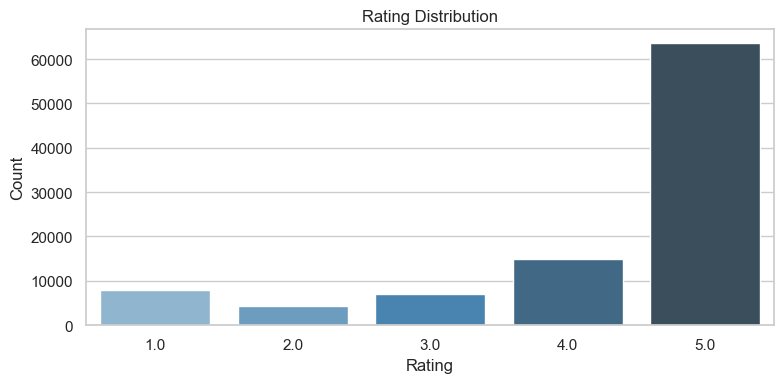

In [16]:
print("=== Rating Distribution ===")
rating_counts = df["rating"].value_counts().sort_index()
print(rating_counts)
print(f"\nAverage rating: {df['rating'].mean():.2f}")

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="rating", palette="Blues_d")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Key finding: Dataset is heavily skewed toward 5★ (65%).
After dropping rating 3, class ratio is ~80:20 positive:negative.
Will use class_weight='balanced' during model training to handle imbalance.

=== Sentiment Split (after dropping rating 3) ===
sentiment
1    78501
0    12257
Name: count, dtype: int64

Positive: 78,501
Negative: 12,257


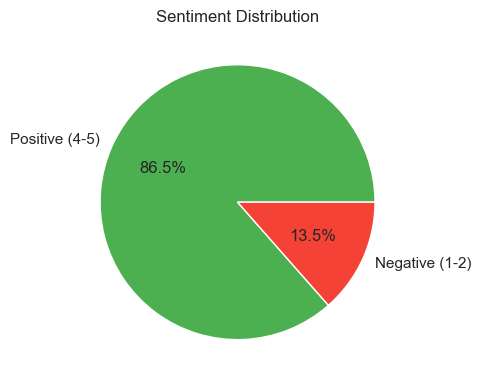

In [17]:
# drop rating 3 — ambiguous, not useful for binary classification
df_clean = df[df["rating"] != 3.0].copy()
df_clean["sentiment"] = (df_clean["rating"] >= 4.0).astype(int)

print("=== Sentiment Split (after dropping rating 3) ===")
print(df_clean["sentiment"].value_counts())
print(f"\nPositive: {(df_clean['sentiment']==1).sum():,}")
print(f"Negative: {(df_clean['sentiment']==0).sum():,}")

labels = ["Positive (4-5)", "Negative (1-2)"]
sizes  = df_clean["sentiment"].value_counts().values
plt.figure(figsize=(6, 4))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=["#4CAF50", "#F44336"])
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

Imbalance ratio: 6.4:1 positive to negative
This means if a model predicts everything as positive
it gets 86.5% accuracy — which looks good but is wrong.

Fix: use class_weight='balanced' in all sklearn models.
This tells the model to penalise mistakes on the minority 
class (negative) more heavily.

=== Review Length (word count) ===
count    97822.00
mean        69.46
std        105.86
min          0.00
25%         14.00
50%         35.00
75%         81.00
max       2665.00
Name: review_length, dtype: float64


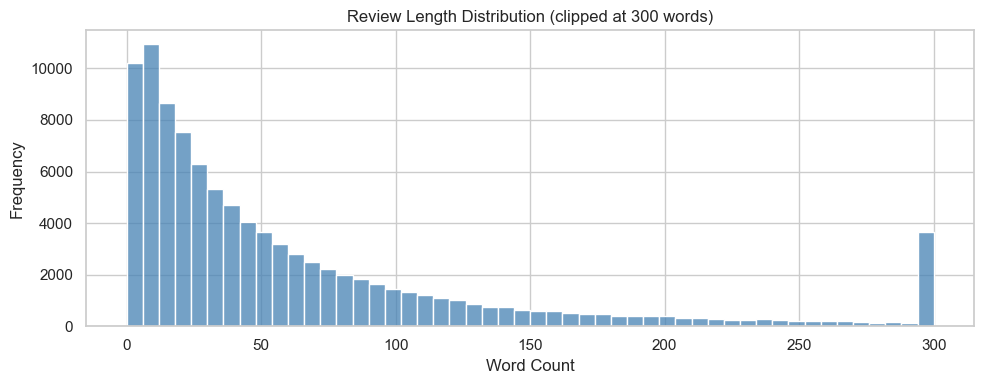


Reviews under 10 words:  17,770
Reviews under 5 words:   8,150


In [19]:
print("=== Review Length (word count) ===")
print(df["review_length"].describe().round(2))

plt.figure(figsize=(10, 4))
sns.histplot(df["review_length"].clip(upper=300), bins=50, color="steelblue")
plt.title("Review Length Distribution (clipped at 300 words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"\nReviews under 10 words:  {(df['review_length'] < 10).sum():,}")
print(f"Reviews under 5 words:   {(df['review_length'] < 5).sum():,}")

In [20]:
# see the empty / very short reviews
print("=== Shortest Reviews ===")
df[df["review_length"] < 5][["rating", "text", "review_length"]].head(10)

=== Shortest Reviews ===


,rating,text,review_length
43,1.0,Arrived damaged,2
44,5.0,Fast charging,2
61,5.0,Works great. No complaints!,4
64,5.0,awesome,1
67,5.0,Gift,1
77,5.0,Love it,2
98,5.0,Great little device!,3
99,4.0,Good warranty!,2
123,5.0,My granddaughter is overjoyed!,4
125,5.0,great gift from wife.,4


In [21]:
# see the longest reviews
print("=== Longest Reviews ===")
df[df["review_length"] > 500][["rating", "text", "review_length"]].head(5)

=== Longest Reviews ===


,rating,text,review_length
351,5.0,Needed a receiver that would allow us to have ...,568
556,1.0,I am going to provide a list of pros and cons....,826
1057,5.0,It amazes me just how much power this little c...,574
1097,5.0,Maybe it is just because I haven't upgraded my...,662
1102,3.0,"When I got this, I assumed it was a complete o...",512


In [22]:
# reviews with exactly 3 or 4 words
borderline = df_clean[df_clean["review_length"].isin([3, 4])]
print(f"Reviews with 3-4 words: {len(borderline):,}")
print("\nSample:")
borderline[["rating", "text", "review_length"]].sample(10, random_state=42)

Reviews with 3-4 words: 3,832

Sample:


,rating,text,review_length
55696,5.0,Just as described.,3
34518,5.0,Hace su trabajo! :D,4
66286,5.0,I love ANker products.,4
57306,5.0,Works really well,3
84172,5.0,great little camera,3
87279,5.0,Really big and sturdy.,4
15079,5.0,GOOGD FOR PRICE,3
85669,5.0,Great clarity 👌,3
83137,5.0,I absolutely love it!,4
45127,5.0,Love this for streaming,4


Cleaning decision: remove reviews under 3 words.
Reason: 1-2 word reviews ("Gift", "awesome") carry zero 
sentiment information useful for ML training.
Reviews 3+ words kept including long ones (max 2665 words) 
— detailed reviews are valuable for aspect extraction.

In [23]:
df_clean = df_clean[df_clean["review_length"] >= 3].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"After removing <3 word reviews: {len(df_clean):,}")
print(f"Positive: {(df_clean['sentiment']==1).sum():,}")
print(f"Negative: {(df_clean['sentiment']==0).sum():,}")

After removing <3 word reviews: 86,738
Positive: 74,723
Negative: 12,015


In [25]:
# convert Period columns to string for SQLite
df_clean["month"] = df_clean["month"].astype(str)

# now save
conn = sqlite3.connect("../data/reviews.db")
df_clean.to_sql("reviews_clean", conn, if_exists="replace", index=False)
conn.close()
print(f"Saved reviews_clean → {len(df_clean):,} rows")

Saved reviews_clean → 86,738 rows


Started:  &ensp;           100,000 rows \
Removed duplicates:  &ensp;   2,178 rows  (spam/bot reviews) \
Removed rating 3:  &ensp;     7,064 rows  (neutral, ambiguous) \
Removed <3 words: &ensp;      4,020 rows  (no ML value) \
─────────────────────────────────────────────   \
Final clean:   &ensp;     86,738 rows \
Positive:    &ensp;       74,723 (86%) \
Negative:     &ensp;      12,015 (14%) 

=== Verified Purchase ===
verified_purchase
True     67715
False    19023
Name: count, dtype: int64


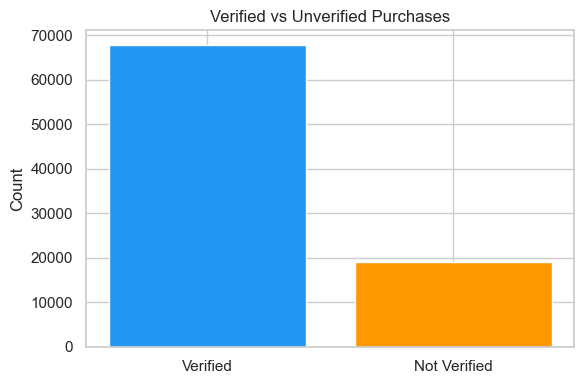

In [27]:
print("=== Verified Purchase ===")
print(df_clean["verified_purchase"].value_counts())

vp = df_clean["verified_purchase"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(["Verified", "Not Verified"], vp.values, color=["#2196F3", "#FF9800"])
plt.title("Verified vs Unverified Purchases")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

=== Top 10 Most Reviewed Products ===
parent_asin
B075X8471B    277
B01K8B8YA8    239
B07GZFM1ZM    222
B010BWYDYA    175
B0791TX5P5    167
B07H65KP63    163
B07KTYJ769    140
B07S764D9V    131
B0BW4PFM58    111
B01MTF2Z37     96
Name: count, dtype: int64


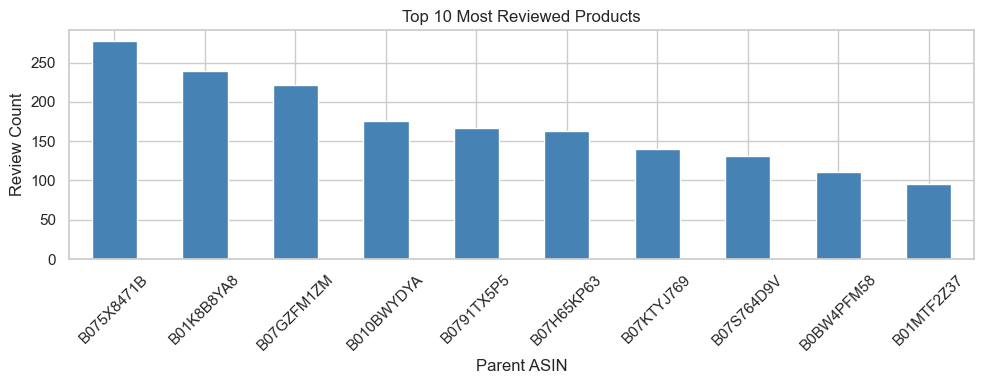

In [28]:
print("=== Top 10 Most Reviewed Products ===")
top_products = df_clean["parent_asin"].value_counts().head(10)
print(top_products)

plt.figure(figsize=(10, 4))
top_products.plot(kind="bar", color="steelblue")
plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Parent ASIN")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top products for LLM comparison module:
B075X8471B, B01K8B8YA8, B07GZFM1ZM — use these as 
default options in the product comparison dropdown.

=== Reviews Over Time ===
month
2022-06     838
2022-07    1053
2022-08    1068
2022-09     902
2022-10    1065
2022-11    1048
2022-12    1195
2023-01    1140
2023-02     864
2023-03     456
dtype: int64


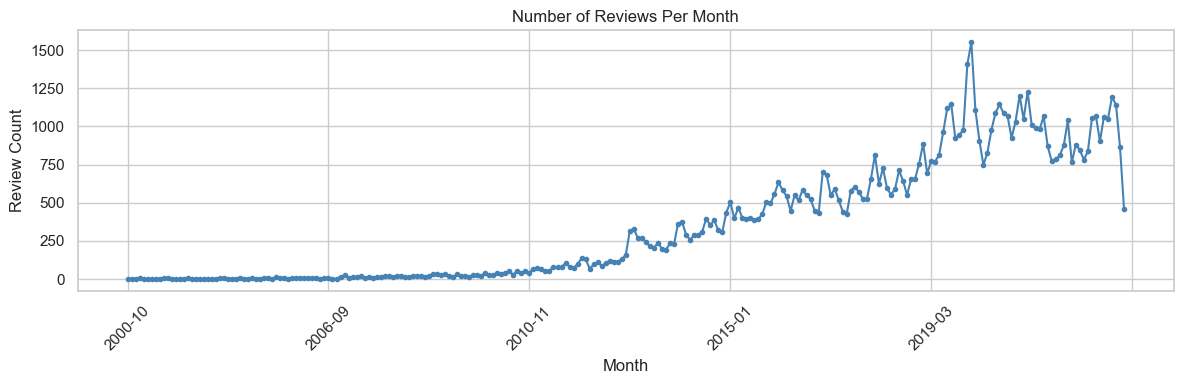

In [29]:
print("=== Reviews Over Time ===")
monthly = df_clean.groupby("month").size()
print(monthly.tail(10))

plt.figure(figsize=(12, 4))
monthly.plot(kind="line", color="steelblue", marker="o", markersize=3)
plt.title("Number of Reviews Per Month")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Correlation Analysis ===
                   rating  review_length  helpful_vote  verified_purchase  \
rating               1.00          -0.04         -0.00              -0.04   
review_length       -0.04           1.00          0.13              -0.33   
helpful_vote        -0.00           0.13          1.00              -0.01   
verified_purchase   -0.04          -0.33         -0.01               1.00   
sentiment            0.95          -0.01         -0.00              -0.07   

                   sentiment  
rating                  0.95  
review_length          -0.01  
helpful_vote           -0.00  
verified_purchase      -0.07  
sentiment               1.00  


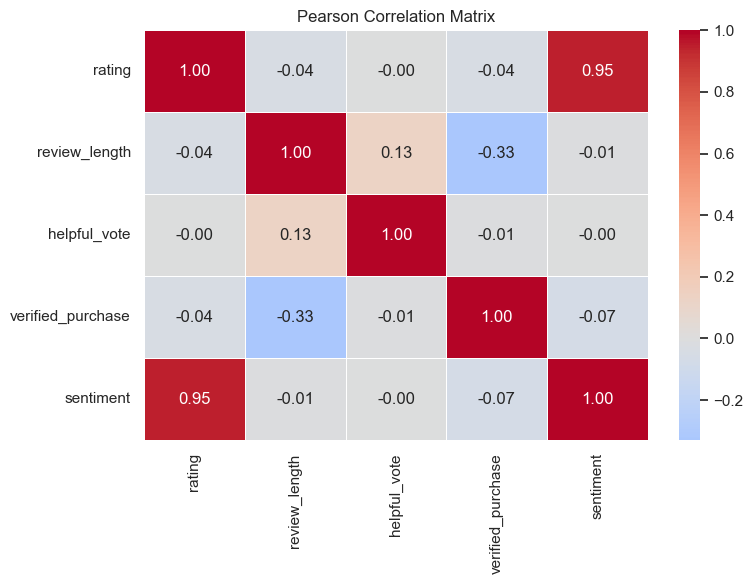

In [30]:
print("=== Correlation Analysis ===")

corr_df = df_clean[["rating", "review_length", "helpful_vote",
                     "verified_purchase", "sentiment"]].copy()
corr_df["verified_purchase"] = corr_df["verified_purchase"].astype(int)

corr_matrix = corr_df.corr().round(2)
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

Key correlation findings:

1. review_length ↔ verified_purchase = -0.33
   Unverified reviewers write longer reviews — possible 
   attempt to appear legitimate. Strong fake review signal.

2. review_length ↔ helpful_vote = 0.13
   Longer reviews get more helpful votes — people appreciate detail.

3. All other correlations weak (<0.1) — features are 
   largely independent, good for ML (no multicollinearity).
   

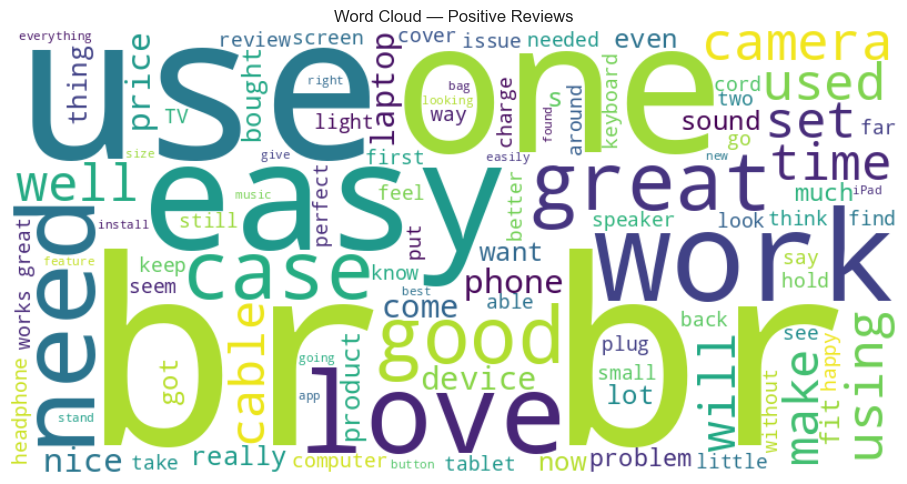

In [31]:
# Cell 14 — positive word cloud
positive_text = " ".join(
    df_clean[df_clean["sentiment"] == 1]["text"].dropna().values
)

wc = WordCloud(width=800, height=400,
               background_color="white",
               max_words=100).generate(positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Positive Reviews")
plt.tight_layout()
plt.show()

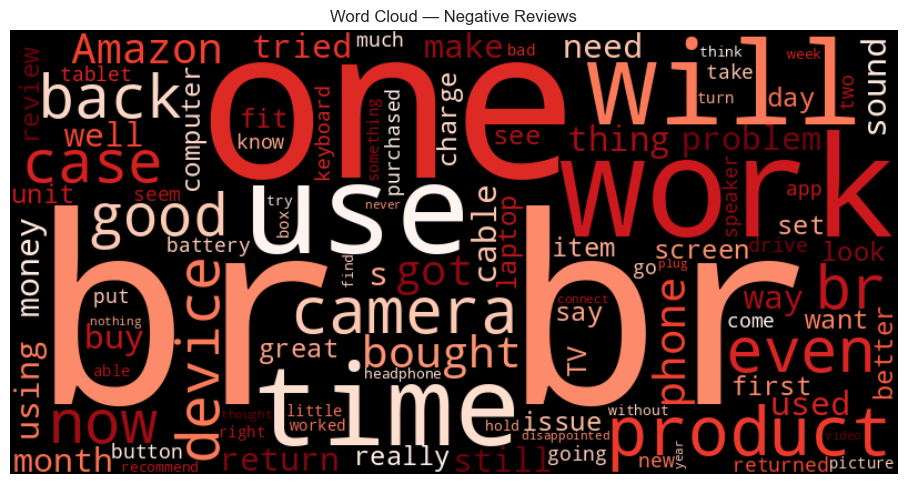

In [32]:
# Cell 15 — negative word cloud
negative_text = " ".join(
    df_clean[df_clean["sentiment"] == 0]["text"].dropna().values
)

wc = WordCloud(width=800, height=400,
               background_color="black",
               colormap="Reds",
               max_words=100).generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Negative Reviews")
plt.tight_layout()
plt.show()

In [33]:
# clean HTML artifacts from text
import re

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)      # remove HTML tags like <br>
    text = re.sub(r'\s+', ' ', text)         # remove extra whitespace
    return text.strip()

df_clean["text"]      = df_clean["text"].apply(clean_text)
df_clean["full_text"] = df_clean["full_text"].apply(clean_text) if "full_text" in df_clean.columns else df_clean["text"]

print("HTML tags cleaned.")
print(df_clean["text"].head(3))

HTML tags cleaned.
0    These didn’t work. Idk if they were damaged in...
1    I love these. They even come with a carry case...
2    I was searching for a sturdy backpack for scho...
Name: text, dtype: object


In [34]:
df_clean["month"] = df_clean["month"].astype(str)

conn = sqlite3.connect("../data/reviews.db")
df_clean.to_sql("reviews_clean", conn, if_exists="replace", index=False)
conn.close()
print(f"Saved clean data → {len(df_clean):,} rows")

Saved clean data → 86,738 rows


Data quality issue found: HTML tag <br> present in review 
text — artifact from web scraping. Removed using regex 
before saving final clean dataset.

Bigram insight: "work" appears in both positive and negative 
clouds. TF-IDF must capture bigrams (doesn't work, works great) 
not just unigrams. Set ngram_range=(1,2) during feature engineering.

In [35]:
df_clean.head(4)

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_length,title_length,month,year,sentiment,full_text
0,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,45,6,2020-06,2020,0,These didn’t work. Idk if they were damaged in...
1,5.0,Excellent!,I love these. They even come with a carry case...,B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,94,1,2018-04,2018,1,I love these. They even come with a carry case...
2,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,203,3,2010-11,2010,1,I was searching for a sturdy backpack for scho...
3,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,44,7,2023-02,2023,1,I've bought these headphones three times becau...


In [36]:
df.head(4)

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_length,title_length,month,year
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,275,5,2022-07,2022
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,45,6,2020-06,2020
2,5.0,Excellent!,I love these. They even come with a carry case...,B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,94,1,2018-04,2018
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,203,3,2010-11,2010


In [39]:
print(df_clean.groupby("parent_asin")["rating"].count().sort_values(ascending=False).head(10))

parent_asin
B075X8471B    277
B01K8B8YA8    239
B07GZFM1ZM    222
B010BWYDYA    175
B0791TX5P5    167
B07H65KP63    163
B07KTYJ769    140
B07S764D9V    131
B0BW4PFM58    111
B01MTF2Z37     96
Name: rating, dtype: int64


In [42]:
df_clean.groupby("parent_asin").get_group("B075X8471B")[["rating", "text"]]

,rating,text
16,4.0,Pretty cool!!! Thanks Amazon.
215,5.0,We love it
340,5.0,i have hemmed and hawed for quite a while abou...
1893,4.0,Oct 2017 Review Update: Amazon has done a grea...
1932,5.0,Love love love. Used to have Google Chromecast...
...,...,...
86017,5.0,Perfect for streaming. They should have kept y...
86230,5.0,works good in getting stations not offered by ...
86272,1.0,This is the 3rd fire stick I've bought and We ...
86432,5.0,We love it best brightest flashlight ever!!! I...
